<h1 style="color:blue;">Task 1: Exploratory Data Analysis (EDA)</h1>

<h2 style="color:green;">Introduction</h2>

EDA is used to understand and explore the dataset before modeling. It helps identify patterns, distributions, and data issues.
In this task, we analyze product reviews, ratings, and sentiment to gain basic insights from the data.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset-SA.csv")

In [3]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [6]:
df = df.dropna(subset=['Review', 'Rate'])

df['product_price'] = df['product_price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')

df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['product_price', 'Rate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180385 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   product_name   180385 non-null  object 
 1   product_price  180385 non-null  int64  
 2   Rate           180385 non-null  float64
 3   Review         180385 non-null  object 
 4   Summary        180376 non-null  object 
 5   Sentiment      180385 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.6+ MB


In [7]:
df.describe()

,product_price,Rate
count,180385.000000,180385.000000
mean,4620.582698,4.143244
std,10438.821036,1.294810
min,59.000000,1.000000
25%,350.000000,4.000000
50%,980.000000,5.000000
75%,3569.000000,5.000000
max,86990.000000,5.000000


In [8]:
print("--- Count of Ratings ---")
print(df['Rate'].value_counts().sort_index())

print("\n--- Count of Sentiments ---")
print(df['Sentiment'].value_counts())

print("\n--- Rating vs Sentiment Cross-tabulation ---")
print(pd.crosstab(df['Rate'], df['Sentiment']))

--- Count of Ratings ---
Rate
1.0     18294
2.0      5451
3.0     14024
4.0     36969
5.0    105647
Name: count, dtype: int64

--- Count of Sentiments ---
Sentiment
positive    147174
negative     24400
neutral       8811
Name: count, dtype: int64

--- Rating vs Sentiment Cross-tabulation ---
Sentiment  negative  neutral  positive
Rate                                  
1.0           16156     1029      1109
2.0            3977      853       621
3.0            2646     3123      8255
4.0             836     1767     34366
5.0             785     2039    102823


In [9]:
print("--- Top 10 Most Reviewed Products ---")
print(df['product_name'].value_counts().head(10))

print("\n--- Average Product Price by Rating ---")
print(df.groupby('Rate')['product_price'].mean())

--- Top 10 Most Reviewed Products ---
product_name
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÃÂ ÃÂ (White, Microwave Safe)                   6005
Lakm?? Eyeconic Kajal Twin Pack??????????(Deep Black, 0.7 g)                                                                                  5000
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                                                             2205
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set 18 Pieces Dinner SetWhite Microwave Safe                               2095
Home Sizzler 153 cm 502 ft Polyester Room Darkening Window Curtain Pack Of 2Floral Brown                                                      2012
Mi 3i 10000 mAh Power Bank (Fast Charging, 18W)ÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ (Blue, Lithium Polymer)                                              2006
Singer FM 1409 Electric Sewing MachineÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ ( B

C:\Users\acer\AppData\Local\Temp\ipykernel_12284\2002432611.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='Rate', palette='viridis')
C:\Users\acer\AppData\Local\Temp\ipykernel_12284\2002432611.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Rate', y='product_price', palette='magma')


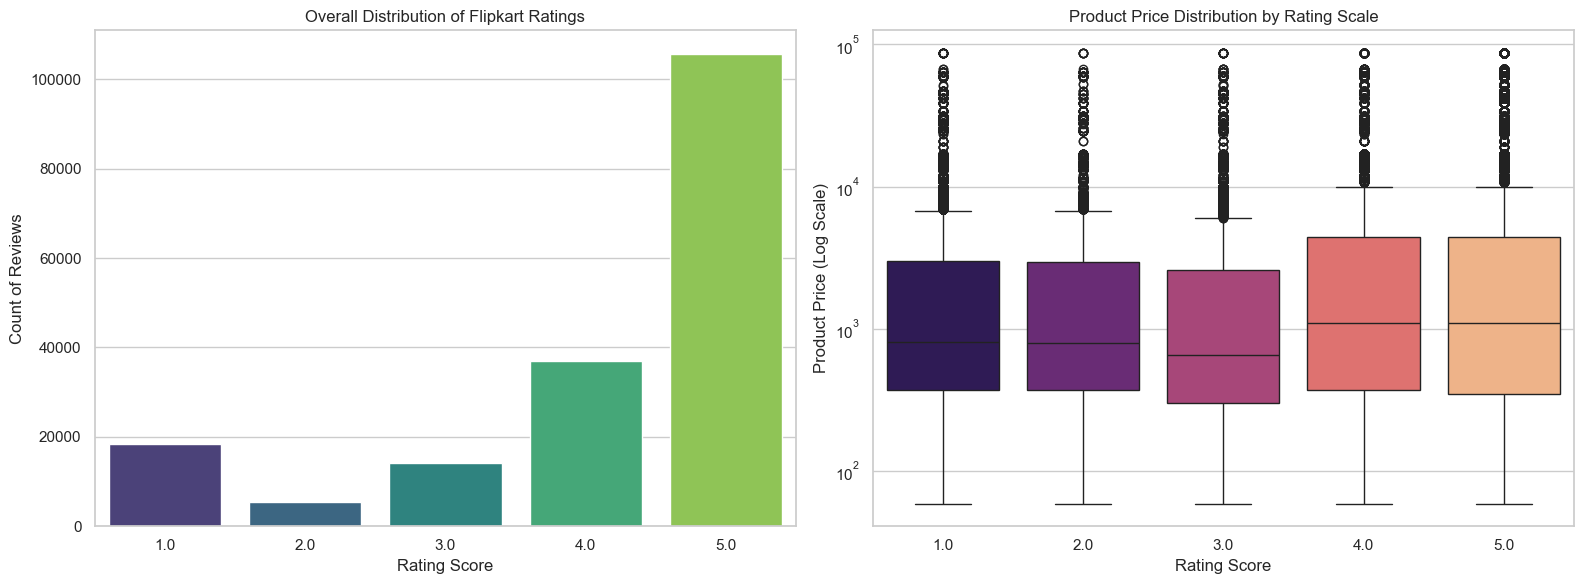

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(ax=axes[0], data=df, x='Rate', palette='viridis')
axes[0].set_title('Overall Distribution of Flipkart Ratings')
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Count of Reviews')

sns.boxplot(ax=axes[1], data=df, x='Rate', y='product_price', palette='magma')
axes[1].set_yscale('log') # Smooths out extreme price outliers for better readability
axes[1].set_title('Product Price Distribution by Rating Scale')
axes[1].set_xlabel('Rating Score')
axes[1].set_ylabel('Product Price (Log Scale)')

plt.tight_layout()
plt.show()